### Denisa notebook

This notebook presents Denisa's process of looking for interesting patterns in the network. 

In [1]:
# Add imports
import urllib
import networkx as nx
import io
import json
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import random
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
from itertools import islice
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import json
import os
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from wordcloud import *

In [4]:
# Load the network
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_project/refs/heads/main/celebrities_clean_without_content.graphml"
    
try:
    with urllib.request.urlopen(url) as response:
        data = response.read()
        
    network = nx.read_graphml(io.BytesIO(data))
    print(f" Network loaded successfully!")
    print(f" Nodes: {network.number_of_nodes()}")
    print(f" Edges: {network.number_of_edges()}")
        
except Exception as e:
    print(f"Error loading network: {str(e)}")
    network = None

 Network loaded successfully!
 Nodes: 11286
 Edges: 125705


I checked the In and Out degree distributions, checking that the network follows a power-law degree distribution.

Maximum In Degree: 414
Minimum In Degree: 0
Maximum Out Degree: 105
Minimum Out Degree: 0


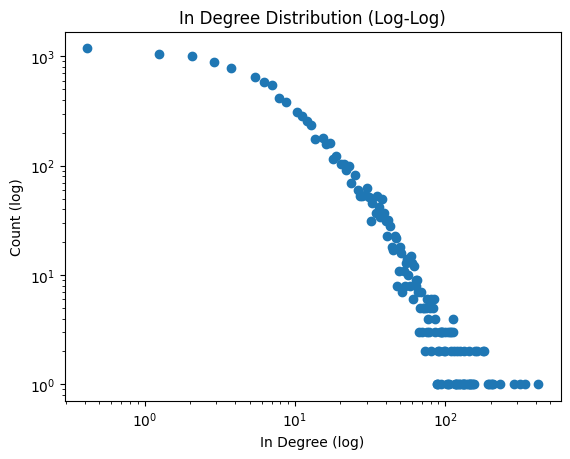

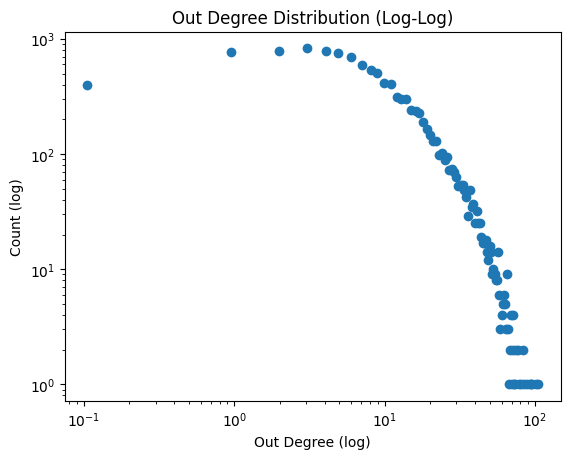

In [7]:
print('Maximum In Degree: ' + str(max(dict(network.in_degree()).values())))
print('Minimum In Degree: ' + str(min(dict(network.in_degree()).values())))

print('Maximum Out Degree: ' + str(max(dict(network.out_degree()).values())))
print('Minimum Out Degree: ' + str(min(dict(network.out_degree()).values())))

counts, bin_edges = np.histogram([deg for node, deg in network.in_degree()], 500)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure()
plt.plot(bin_centers, counts, 'o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('In Degree (log)')
plt.ylabel('Count (log)')
plt.title('In Degree Distribution (Log-Log)')
plt.show()

counts, bin_edges = np.histogram([deg for node, deg in network.out_degree()], 500)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure()
plt.plot(bin_centers, counts, 'o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Out Degree (log)')
plt.ylabel('Count (log)')
plt.title('Out Degree Distribution (Log-Log)')
plt.show()

I checked the assortativity of the network - expecting high-degree nodes to connect with other high-degree nodes.

In [22]:
# Degree assortativity
assortativity = nx.degree_assortativity_coefficient(network)
print(f"Degree assortativity: {assortativity:.4f}")

Degree assortativity: 0.0631


Since we settled on making an analysis across time, I defined my eras based on the main human history eras. A person is assigned to an era if their birth year is in the time interval defined for the specific era.

In [11]:
era_order_display = [
    'Before Christ (< 30)',
    'Classical Era (30-476)',
    'Middle Ages (476-1450)',
    'Early Modern (1450-1760)',
    'Industrial Era (1760-1840)',
    'Wartime (1840-1945)',
    'Post-War (1945-2025)'
]

def get_era(birth_year):
    """Determine which era a birth year belongs to"""
    if birth_year is None:
        return 'Unknown'
    
    try:
        year = int(birth_year)
    except (ValueError, TypeError):
        return 'Unknown'
    
    if year < 30:
        return 'Before Christ (< 30)'
    elif 30 <= year < 476:
        return 'Classical Era (30-476)'
    elif 476 <= year < 1450:
        return 'Middle Ages (476-1450)'
    elif 1450 <= year < 1760:
        return 'Early Modern (1450-1760)'
    elif 1760 <= year < 1840:
        return 'Industrial Era (1760-1840)'
    elif 1840 <= year < 1945:
        return 'Wartime (1840-1945)'
    elif 1945 <= year <= 2025:
        return 'Post-War (1945-2025)'
    else:
        return 'Unknown'

My main path of focus was birth cities, seeing if I can find some interesting patterns emerging from them. I wanted to see the total number of cities and what are the ones with the most influential people being born there.

In [9]:
# Group nodes by birth city
from collections import defaultdict

city_groups = defaultdict(list)

for node in network.nodes():
    birth_city = network.nodes[node].get('birthcity', 'Unknown')
    city_groups[birth_city].append(node)

# Print summary
print(f"Total unique birth cities: {len(city_groups)}\n")

# Show top 10 cities by number of people
sorted_cities = sorted(city_groups.items(), key=lambda x: len(x[1]), reverse=True)

print("Top 10 cities by number of people:")
for i, (city, people) in enumerate(sorted_cities[:10], 1):
    print(f"{i:2d}. {city:30s} - {len(people):4d} people")
    # Show first 3 people from this city
    for person in people[:3]:
        print(f"     - {person}")
    if len(people) > 3:
        print(f"     ... and {len(people) - 3} more")
    print()

Total unique birth cities: 5074

Top 10 cities by number of people:
 1. OTHER                          -  505 people
     - 37
     - 197
     - 451
     ... and 502 more

 2. NEW YORK                       -  338 people
     - 8844
     - 8845
     - 8846
     ... and 335 more

 3. PARIS                          -  244 people
     - 1631
     - 1642
     - 1669
     ... and 241 more

 4. LOS ANGELES                    -  190 people
     - 8691
     - 8692
     - 8693
     ... and 187 more

 5. LONDON                         -  177 people
     - 919
     - 944
     - 947
     ... and 174 more

 6. ROME                           -  170 people
     - 3954
     - 3973
     - 3977
     ... and 167 more

 7. CHICAGO                        -  107 people
     - 8729
     - 8730
     - 8732
     ... and 104 more

 8. MOSCOW                         -  104 people
     - 5927
     - 5930
     - 5935
     ... and 101 more

 9. ISTANBUL                       -   76 people
     - 1208
     - 7173
  

I removed the 'Other' option and the cities which only had 1 person being born there.

In [24]:
top_cities = sorted_cities[1:1216]

print(f"Top cities (total: {len(top_cities)})")
for i, (city, people) in enumerate(top_cities, 1):
    print(f"{i:2d}. {city:30s} - {len(people):4d} people")

Top cities (total: 1215)
 1. NEW YORK                       -  338 people
 2. PARIS                          -  244 people
 3. LOS ANGELES                    -  190 people
 4. LONDON                         -  177 people
 5. ROME                           -  170 people
 6. CHICAGO                        -  107 people
 7. MOSCOW                         -  104 people
 8. ISTANBUL                       -   76 people
 9. VIENNA                         -   74 people
10. BOSTON                         -   65 people
11. BERLIN                         -   63 people
12. SAN FRANCISCO-BAY AREA         -   62 people
13. SAINT PETERSBURG               -   52 people
14. FLORENCE                       -   50 people
15. BUENOS AIRES                   -   43 people
16. MADRID                         -   43 people
17. MUNICH                         -   42 people
18. BUDAPEST                       -   38 people
19. STOCKHOLM                      -   38 people
20. COPENHAGEN                     -   37 pe

I grouped the influential people by era and birth city.

In [25]:
city_era_groups = {}

for city, people in top_cities:
    city_era_groups[city] = defaultdict(list)
    
    for person in people:
        birth_year = network.nodes[person].get('birthyear', None)
        era = get_era(birth_year)
        city_era_groups[city][era].append(person)

I continued by looking into how different centrality measures change across eras.

In [20]:
# Calculate multiple centrality measures per era
centrality_evolution = []

for era in era_order_display:
    era_nodes = []
    for city, people in top_cities:
        if city in city_era_groups and era in city_era_groups[city]:
            era_nodes.extend(city_era_groups[city][era])
    
    if len(era_nodes) > 5:
        era_subgraph = network.subgraph(era_nodes)
        
        # Calculate centralities
        degree_cent = nx.degree_centrality(era_subgraph)
        between_cent = nx.betweenness_centrality(era_subgraph)
        close_cent = nx.closeness_centrality(era_subgraph)
        
        # Get top nodes by each measure
        top_degree = max(degree_cent.items(), key=lambda x: x[1])
        top_between = max(between_cent.items(), key=lambda x: x[1])
        top_close = max(close_cent.items(), key=lambda x: x[1])
        
        centrality_evolution.append({
            'era': era,
            'top_degree': network.nodes[top_degree[0]].get('Name'),
            'top_betweenness': network.nodes[top_between[0]].get('Name'),
            'top_closeness': network.nodes[top_close[0]].get('Name'),
            'avg_degree': sum(degree_cent.values())/len(degree_cent)
        })

df_cent = pd.DataFrame(centrality_evolution)
print(df_cent)

                          era           top_degree      top_betweenness  \
0        Before Christ (< 30)                Plato                Plato   
1      Classical Era (30-476)               Trajan        Constantine I   
2      Middle Ages (476-1450)          Charlemagne          Charlemagne   
3    Early Modern (1450-1760)  Louis XIV of France  Louis XIV of France   
4  Industrial Era (1760-1840)       Queen Victoria          Victor Hugo   
5         Wartime (1840-1945)      John F. Kennedy        Ronald Reagan   
6        Post-War (1945-2025)         Barack Obama        David Beckham   

       top_closeness  avg_degree  
0             Cicero    0.058063  
1  Septimius Severus    0.056247  
2        Charlemagne    0.016470  
3           Voltaire    0.019561  
4     Queen Victoria    0.015934  
5    John F. Kennedy    0.004570  
6       Barack Obama    0.005866  


I looked for communities using Louvain partitioning.

In [ ]:
# Louvain community detection
from networkx.algorithms import community

communities = community.louvain_communities(network)

print(f"Found {len(communities)} communities")

# Analyze top 5 communities
for i, comm in enumerate(sorted(communities, key=len, reverse=True)[:5], 1):
    print(f"\nCommunity {i}: {len(comm)} members")
    
    # Check which occupations dominate this community
    occupations = [network.nodes[node].get('occupation', 'Unknown') for node in comm]
    top_occupations = Counter(occupations).most_common(3)
    print(f"  Top occupations: {top_occupations}")
    
    # Check what cities dominate the community
    cities = [network.nodes[node].get('birthcity', 'Unknown') for node in comm]
    top_cities = Counter(cities).most_common(3)
    print(f"  Top cities: {top_cities}")
    
    # Sample members
    sample_names = [network.nodes[node].get('Name') for node in list(comm)[:5]]
    print(f"  Sample: {sample_names}")

Found 255 communities

Community 1: 2004 members
  Top occupations: [('POLITICIAN', 1219), ('MILITARY PERSONNEL', 114), ('WRITER', 98)]
  Top cities: [('LONDON', 30), ('NEW YORK', 27), ('MOSCOW', 26)]
  Sample: ['Dmitry Medvedev', 'Andreas Papandreou', 'Ayman al-Zawahiri', 'Felix Wankel', 'Eva Braun']

Community 2: 1753 members
  Top occupations: [('ACTOR', 1083), ('WRITER', 288), ('FILM DIRECTOR', 167)]
  Top cities: [('NEW YORK', 170), ('LOS ANGELES', 107), ('CHICAGO', 55)]
  Sample: ['Charlotte Rampling', 'Jafar Panahi', 'Elizabeth Taylor', 'James Coburn', 'Sterling Knight']

Community 3: 1260 members
  Top occupations: [('POLITICIAN', 251), ('WRITER', 248), ('PHILOSOPHER', 149)]
  Top cities: [('PARIS', 85), ('LONDON', 37), ('MOSCOW', 28)]
  Sample: ['Timothy McVeigh', 'Howard Gardner', 'Pierre-Simon Laplace', 'Honoré de Balzac', 'Romain Rolland']

Community 4: 1125 members
  Top occupations: [('SOCCER PLAYER', 1026), ('COACH', 73), ('REFEREE', 10)]
  Top cities: [('BUENOS AIRES', 

After the broader analysis based on the concepts seen in the lectures, I did a deeper analysis on my assigned focus path: birth cities of influential people.

In order to have a better overview of the cities, I created a heatmap showing the distribuiton of people by city and era in the cities with the most influential people.

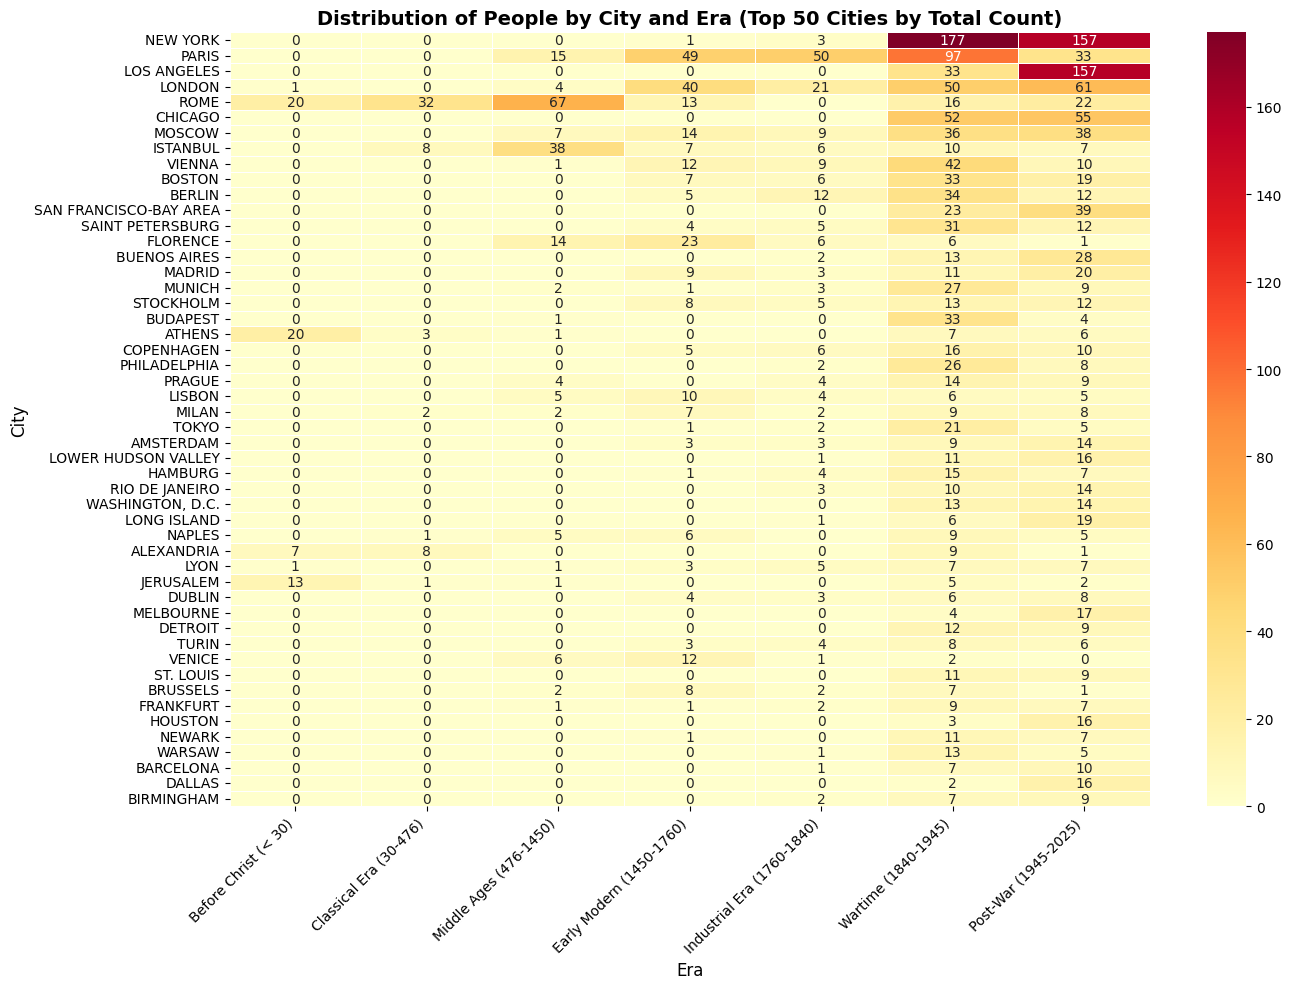

In [27]:
# Heatmap of top cities sorted by total people count
# Sort the pivot table by total count across all eras
# Create summary statistics
summary_data = []

for city, people in top_cities:
    era_dict = city_era_groups[city]
    
    for era, era_people in era_dict.items():
        summary_data.append({
            'city': city,
            'era': era,
            'count': len(era_people)
        })

df_summary = pd.DataFrame(summary_data)

# Pivot to show cities vs eras
df_pivot = df_summary.pivot(index='city', columns='era', values='count').fillna(0).astype(int)

# Reorder columns chronologically
era_order = [
    'Before Christ (< 30)',
    'Classical Era (30-476)',
    'Middle Ages (476-1450)',
    'Early Modern (1450-1760)',
    'Industrial Era (1760-1840)',
    'Wartime (1840-1945)',
    'Post-War (1945-2025)',
    'Unknown'
]

df_pivot = df_pivot[[col for col in era_order if col in df_pivot.columns]]

df_pivot_sorted = df_pivot.copy()
df_pivot_sorted['total'] = df_pivot_sorted.sum(axis=1)
df_pivot_sorted = df_pivot_sorted.sort_values('total', ascending=False)
df_pivot_sorted = df_pivot_sorted.drop('total', axis=1)

# Plot top 50 cities
plt.figure(figsize=(14, 10))
sns.heatmap(df_pivot_sorted.head(50), annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Distribution of People by City and Era (Top 50 Cities by Total Count)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Era', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

I continued visualising cities with most people by eras.

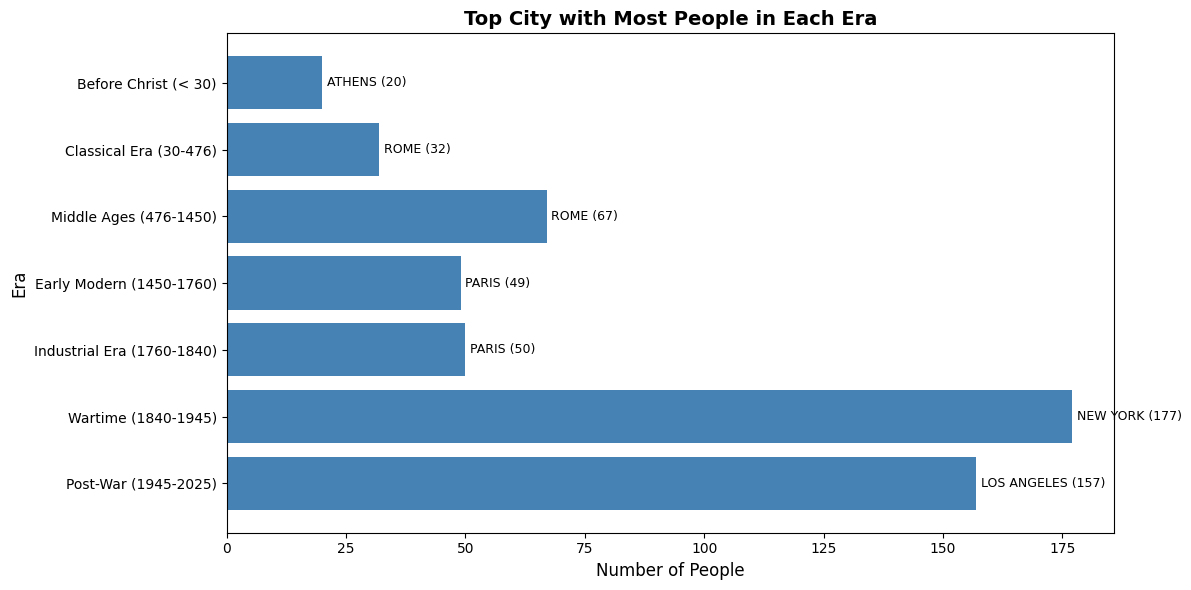

In [28]:
# Create visualization of top city per era
top_cities_per_era = []

for era in era_order:
    if era in df_pivot.columns and df_pivot[era].max() > 0:
        top_city = df_pivot[era].idxmax()
        top_count = df_pivot[era].max()
        top_cities_per_era.append({
            'era': era,
            'city': top_city,
            'count': top_count
        })

df_top = pd.DataFrame(top_cities_per_era)

# Plot
plt.figure(figsize=(12, 6))
bars = plt.barh(df_top['era'], df_top['count'], color='steelblue')

# Add city names on the bars
for i, (era, city, count) in enumerate(zip(df_top['era'], df_top['city'], df_top['count'])):
    plt.text(count + 1, i, f'{city} ({count})', va='center', fontsize=9)

plt.xlabel('Number of People', fontsize=12)
plt.ylabel('Era', fontsize=12)
plt.title('Top City with Most People in Each Era', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

I checked the top 5 cities with most influential people in each era.

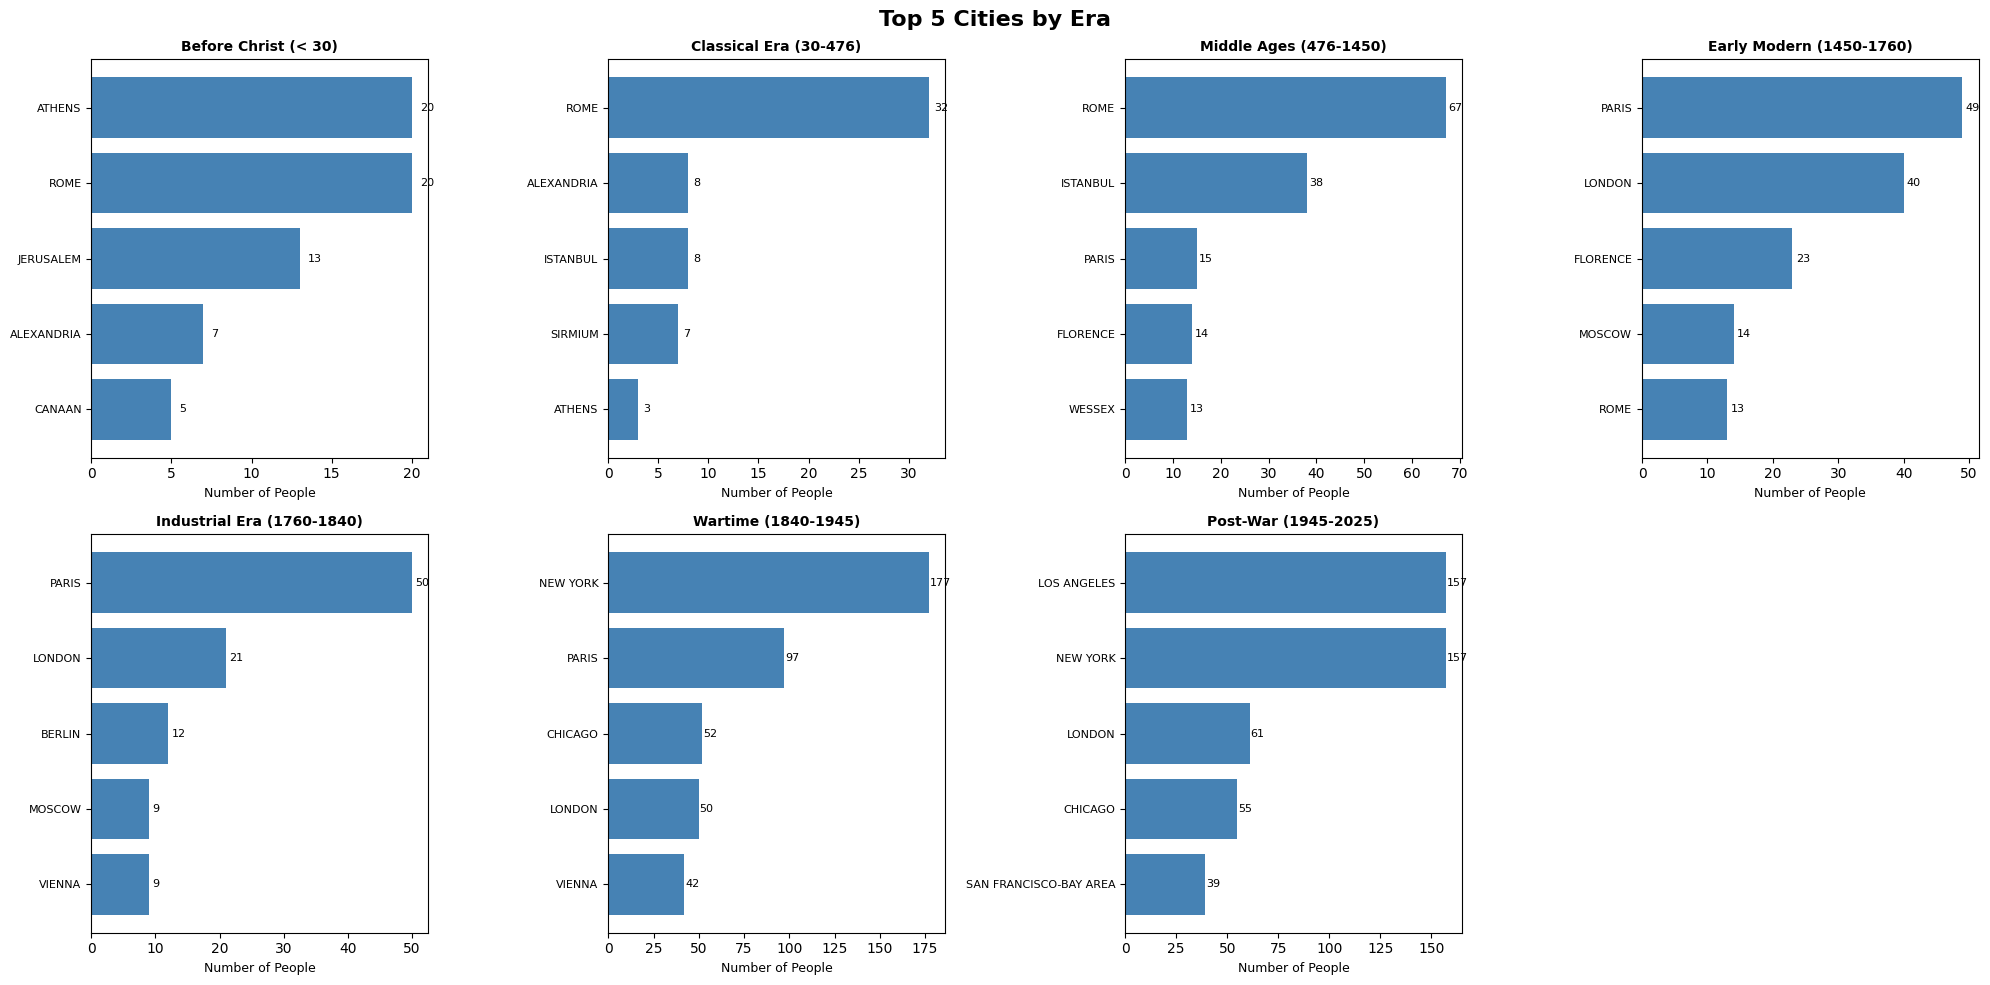

In [29]:
# Create grouped bar chart for top 5 cities per era
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, era in enumerate([e for e in era_order if e in df_pivot.columns and df_pivot[e].max() > 0]):
    # Get top 5 cities for this era
    top_5 = df_pivot[era].nlargest(5)
    
    ax = axes[idx]
    ax.barh(range(len(top_5)), top_5.values, color='steelblue')
    ax.set_yticks(range(len(top_5)))
    ax.set_yticklabels(top_5.index, fontsize=8)
    ax.set_xlabel('Number of People', fontsize=9)
    ax.set_title(f'{era}', fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    
    # Add count labels on bars
    for i, v in enumerate(top_5.values):
        ax.text(v + 0.5, i, str(int(v)), va='center', fontsize=8)

# Hide unused subplots
for idx in range(len([e for e in era_order if e in df_pivot.columns and df_pivot[e].max() > 0]), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Top 5 Cities by Era', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

One idea that we wanted to explore was to check whether we could find a correlation between the 'sentiment' of a city and the number of influential people being born there. We decided to define the 'sentiment' of the city as the average sentiment of the Wiki pages of the people born in a city. As the Wikipedia pages have a neutral tone, there was no clear relationship between the cities and the total number of famous people coming from them. Below is the sentiment analysis with the results, however this is not included in the paper.

In [30]:
nx.set_node_attributes(network, "", "sentiment")

In [31]:
def parse_labmit_file(file_content):
    word_scores = {}
    lines = file_content.strip().split('\n')
    
    # Skip header lines (first 3 lines)
    for line in lines[3:]:
        parts = line.split('\t')
        if len(parts) >= 3:
            word = parts[0].strip()
            try:
                happiness_avg = float(parts[2].strip())
                word_scores[word] = happiness_avg
            except ValueError:
                continue
    
    return word_scores


# Load the labMT file from GitHub
url = "https://raw.githubusercontent.com/denisababeii/socialgraphs_project/refs/heads/main/labMT_wordlist.txt"
    
try:
    with urllib.request.urlopen(url) as response:
        labmt_content = response.read()
    word_scores = parse_labmit_file(labmt_content)
    print(f"Loaded {len(word_scores)} words with happiness scores")
except Exception as e:
    print(f"Error loading file: {str(e)}")
    word_scores = {}

Error loading file: a bytes-like object is required, not 'str'
